# $\mathrm{Displacement~Field}$

In [1]:
import numpy as np
import readgadget
import matplotlib.pyplot as plt

In [2]:
boxsize     = 1000.0                  #--Full box edge length
grid        = 512
subboxsize  = 250                     #--Subbox edge length
subboxes    = int(boxsize/subboxsize) #--Subboxes along one dimension.
resolution  = int(grid/subboxes)      #--Particles along one dimension. 
realization = 0
subboxes, resolution

(4, 128)

In [3]:
# QUIJOTE
root_quijote = f"/data/jborjuel/data/Snapshots/fR_pppp/{realization}"
# Path to ICs 
path_ICs_quij = f"{root_quijote}/ICs/ics"
# Path to snapshot at z = 0
path_snaps_quij = f"{root_quijote}/snapdir_004/snap_004"

In [4]:
# COLA
root_cola = "/data/jborjuel/sims/fR/fR_pppp/fR_pppp_0"
# Path to ICs from cola at z = 127
path_ICs_cola = f"{root_cola}/fR_pppp_0_z127p000"
# Path to snapshot at z = 0
path_snaps_cola = f"{root_cola}/fR_pppp_0_z0p000"

In [5]:
#QUIJOTE 
ids_i_quij  = readgadget.read_block(path_ICs_quij, "ID  ", ptype=[1])-1
pos_i_quij  = readgadget.read_block(path_ICs_quij, "POS ", ptype=[1])/1e3
# Sorted Quijote initial positions 
pos_i_quij = pos_i_quij[np.argsort(ids_i_quij)]

ids_f_quij  = readgadget.read_block(path_snaps_quij, "ID  ", ptype=[1])-1
pos_f_quij  = readgadget.read_block(path_snaps_quij, "POS ", ptype=[1])/1e3
# Sorted Quijote final positions 
pos_f_quij = pos_f_quij[np.argsort(ids_f_quij)]    

In [6]:
#COLA
ids_i_cola  = readgadget.read_block(path_ICs_cola, "ID  ", ptype=[1])
pos_i_cola  = readgadget.read_block(path_ICs_cola, "POS ", ptype=[1])
# Sorted cola initial positions 
pos_i_cola  = pos_i_cola[np.argsort(ids_i_cola)]

ids_f_cola  = readgadget.read_block(path_snaps_cola, "ID  ", ptype=[1])
pos_f_cola  = readgadget.read_block(path_snaps_cola, "POS ", ptype=[1])
# Sorted cola final positions
pos_f_cola = pos_f_cola[np.argsort(ids_f_cola)]

In [7]:
# QUIJOTE
# Normalize positions --> scale to grid coordinates [0, 512] --> Placed in a grid cell 
grid_index_3D_quij = (np.round((pos_i_quij/boxsize)*512.0, decimals=0)).astype(np.int32)
# Periodic boundary conditions
grid_index_3D_quij[np.where(grid_index_3D_quij==512)] = 0
# Convert grid indices back to position space
pos_lag_quij = grid_index_3D_quij*boxsize/512.0
# Compute the equivalent 1D index for each grid cell (row-major order: x fastest, z slowest).
grid_index_1D_quij = grid_index_3D_quij[:,0]*512**2 + grid_index_3D_quij[:,1]*512 + grid_index_3D_quij[:,2]
# Aligning particles with grid cells.
indexes2_quij = np.argsort(grid_index_1D_quij)

In [8]:
# COLA
# Normalize positions --> scale to grid coordinates [0, 512] --> Placed in a grid cell 
grid_index_3D_cola = (np.round((pos_i_cola/boxsize)*512.0, decimals=0)).astype(np.int32)
# Periodic boundary conditions
grid_index_3D_cola[np.where(grid_index_3D_cola==512)] = 0
# Convert grid indices back to position space
pos_lag_cola = grid_index_3D_cola*boxsize/512.0
# Compute the equivalent 1D index for each grid cell (row-major order: x fastest, z slowest).
grid_index_1D_cola = grid_index_3D_cola[:,0]*512**2 + grid_index_3D_cola[:,1]*512 + grid_index_3D_cola[:,2]
# Aligning particles with grid cells.
indexes2_cola   = np.argsort(grid_index_1D_cola)

In [9]:
# QUIJOTE
# Initial and final positions are sorted by their corresponding grid index.
pos_f_quij = pos_f_quij[indexes2_quij]
pos_lag_quij = pos_lag_quij[indexes2_quij]

In [10]:
# COLA
# Initial and final positions are sorted by their corresponding grid index.
pos_f_cola = pos_f_cola[indexes2_cola]
pos_lag_cola = pos_lag_cola[indexes2_cola]

In [11]:
# QUIJOTE
# Displacement field from Quijote
disp_quij = pos_f_quij - pos_lag_quij
disp_quij [disp_quij < -boxsize/2.0] += boxsize
disp_quij [disp_quij >  boxsize/2.0] -= boxsize

In [12]:
# COLA
# Displacement field from cola
disp_cola = pos_f_cola - pos_lag_cola
disp_cola [disp_cola < -boxsize/2.0] += boxsize
disp_cola [disp_cola >  boxsize/2.0] -= boxsize

In [13]:
# Residual displacement field
residual_cola = disp_quij - disp_cola
residual_cola[residual_cola < -boxsize/2.0] += boxsize
residual_cola[residual_cola >  boxsize/2.0] -= boxsize

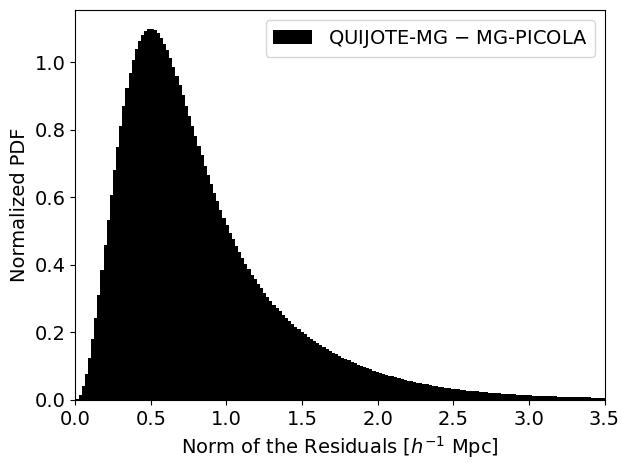

In [14]:
norm_residual_cola  = np.linalg.norm(residual_cola, axis=1)

plt.xlim(0, 3.5)
plt.hist(norm_residual_cola, bins=1000, alpha=1, label=r"QUIJOTE-MG $-$ MG-PICOLA", color='black', density=True)

plt.xlabel(r'Norm of the Residuals [$h^{-1}$ Mpc]', fontsize=14)
plt.ylabel('Normalized PDF', fontsize=14)

plt.tick_params(axis='both', which='major', labelsize=14)

plt.legend(fontsize=14)
plt.tight_layout()
plt.show()

In [15]:
# QUIJOTE
disp_quij_reshape = disp_quij.T.reshape(3, grid, grid, grid).astype(np.float32)
print(disp_quij_reshape.shape)
np.save('/data/jborjuel/NN/fR_pppp/quijote_0.npy', disp_quij_reshape)

(3, 512, 512, 512)


In [16]:
# COLA
disp_cola_reshape = disp_cola.T.reshape(3, grid, grid, grid).astype(np.float32)
print(disp_cola_reshape.shape)
np.save('/data/jborjuel/NN/fR_pppp/cola_0.npy', disp_cola_reshape)

(3, 512, 512, 512)


In [17]:
# QUIJOTE
data_disp_quij = np.load('/data/jborjuel/NN/fR_pppp/quijote_0.npy').reshape(3, -1).T
print("disp_quij coincide?:", np.allclose(disp_quij, data_disp_quij))

disp_quij coincide?: True


In [18]:
# COLA
data_disp_cola = np.load('/data/jborjuel/NN/fR_pppp/cola_0.npy').reshape(3, -1).T
print("disp_cola coincide?:", np.allclose(disp_cola, data_disp_cola))

disp_cola coincide?: True
